# Шаг 6 — KNN с учётом средних (`KNNWithMeans`, surprise + Optuna)

Обучаем memory-based коллаборативную фильтрацию `KNNWithMeans`, подбираем
гиперпараметры через Optuna и оцениваем качество по RMSE и top-N,
сравнивая с GlobalMean / Popularity / SVD из предыдущих шагов.

Ключевое преимущество KNN перед SVD — **интерпретируемость**:
для каждой рекомендации можно показать, какие похожие фильмы её обосновывают.

## Методологические замечания

**Optuna оптимизирует NDCG@10, а не RMSE.**
В первой версии ноутбука Optuna минимизировала RMSE — модель получала NDCG@10 ≈ 0.05,
что хуже даже Popularity-baseline. Причина та же, что в шаге 5:
*regression to the mean*. При оптимизации RMSE Optuna находила параметры,
при которых модель часто падала в fallback-режим (глобальное среднее),
а разница предсказаний между топ-1 и топ-100 становилась ничтожной.

**`user_based=False` и `sim_name='cosine'` зафиксированы до Optuna.**
Item-based устойчивее на MovieLens-Small: фильмов больше, чем пользователей,
у каждого фильма больше оценщиков — матрица сходства плотнее.
`pearson_baseline` при нулевом пересечении оценщиков даёт similarity = 0,
что ломает раздел интерпретируемости. `cosine` — чище.
Зафиксировав эти параметры, тратим весь бюджет trials на `k`, `min_k`, `min_support`.

**Порог релевантности — 3.5**, как в SVD-ноутбуке.
Popularity и SVD пересчитываются под тот же порог для честного сравнения.

## Место в проекте

```
notebooks/
├── 04_model_popularity.ipynb    baseline'ы
├── 05_model_svd.ipynb           SVD
├── 06_model_knn.ipynb           ◄── вы здесь
├── 07_model_lightgbm.ipynb
└── ...
```

## Артефакты (сохраняются в `models/`)

| Файл | Описание |
|------|---------|
| `knn_model.pkl` | Финальная KNN (train + val) — осторожно, ~240 MB |
| `knn_params.json` | Лучшие параметры + зафиксированные настройки |
| `knn_metrics.json` | RMSE/MAE и top-N метрики на test |
| `knn_optuna_trials.parquet` | История 20 trials |


## 0. Импорты и настройки


In [ ]:
import sys
sys.path.append('..')

from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import optuna.visualization as ov
from surprise import KNNWithMeans, Dataset, Reader

from src.utils import SEED, set_seeds
from src.data_io import load_splits, load_features, load_id_maps
from src.metrics import (
    rmse, mae,
    evaluate_rating_prediction, evaluate_topn,
    build_ground_truth,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)
set_seeds()

MODELS_DIR    = Path('../models')
PROCESSED_DIR = Path('../data/processed')

RELEVANCE_THRESHOLD = 3.5
K_PRIMARY           = 10
K_VALUES            = (5, 10, 20)


FIXED_USER_BASED = False
FIXED_SIM_NAME   = 'cosine'

print(f"SEED                = {SEED}")
print(f"optuna version      = {optuna.__version__}")
print(f"relevance threshold = {RELEVANCE_THRESHOLD}")
print(f"fixed user_based    = {FIXED_USER_BASED}")
print(f"fixed sim_name      = {FIXED_SIM_NAME}")

SEED                = 29042005
optuna version      = 4.2.1
relevance threshold = 3.5
fixed user_based    = False
fixed sim_name      = cosine


## 1. Загрузка данных


In [3]:
splits          = load_splits()
train, val, test = splits['train'], splits['val'], splits['test']
features        = load_features()
movies_enriched = features['movies_enriched']
maps            = load_id_maps()

print(f"train: {len(train):,} | val: {len(val):,} | test: {len(test):,}")
print(f"Пользователей (train): {train['userId'].nunique()}")
print(f"Фильмов (train):       {train['movieId'].nunique()}")

train: 68,829 | val: 12,289 | test: 11,728
Пользователей (train): 610
Фильмов (train):       5446


## 2. Подготовка данных в формате Surprise

`KNNWithMeans` учитывает средний рейтинг пользователя или фильма
и предсказывает отклонение от него как взвешенное среднее по соседям.
Это снимает смещение из-за разной «строгости» пользователей (один ставит 3 там,
где другой поставит 5) — в отличие от базового `KNNBasic`.


In [4]:
reader = Reader(rating_scale=(0.5, 5.0))


def df_to_surprise_trainset(df: pd.DataFrame):
    """Из DataFrame [userId, movieId, rating] построить Surprise Trainset."""
    data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)
    return data.build_full_trainset()


trainset = df_to_surprise_trainset(train)
print(f'Surprise trainset: {trainset.n_users} users, '
      f'{trainset.n_items} items, {trainset.n_ratings} ratings')

Surprise trainset: 610 users, 5446 items, 68829 ratings


## 2.5 Вспомогательные функции

Генерация top-N та же, что в шаге 5 — переиспользуем функцию
внутри Optuna objective и при финальной оценке на test.


In [5]:
def predict_ratings_batch(model, user_ids: np.ndarray,
                          movie_ids: np.ndarray) -> np.ndarray:
    """Векторно предсказать рейтинги для пар (user, item)."""
    return np.array([
        model.predict(uid=u, iid=m).est
        for u, m in zip(user_ids, movie_ids)
    ])


def generate_topn_recommendations(model, user_ids, seen_df, all_movies, k=20):
    """Ранжировать все непросмотренные фильмы для каждого пользователя и взять топ-K."""
    seen_by_user = seen_df.groupby('userId')['movieId'].apply(set).to_dict()
    all_movies = np.asarray(all_movies)
    recommendations = {}
    for user_id in user_ids:
        seen       = seen_by_user.get(user_id, set())
        candidates = all_movies[~np.isin(all_movies, list(seen))]
        scores     = predict_ratings_batch(
            model,
            np.full(len(candidates), user_id),
            candidates,
        )
        top_k_idx  = np.argsort(-scores)[:k]
        recommendations[user_id] = candidates[top_k_idx].tolist()
    return recommendations


# Подготовка ground truth для val
val_ground_truth   = build_ground_truth(val, relevance_threshold=RELEVANCE_THRESHOLD)
val_users_for_topn = list(val_ground_truth.keys())
all_movies_train   = train['movieId'].unique()

print(f"Пользователей в val с релевантным GT (≥{RELEVANCE_THRESHOLD}): "
      f"{len(val_users_for_topn)}")
print(f"Кандидатный пул фильмов (train): {len(all_movies_train)}")

Пользователей в val с релевантным GT (≥3.5): 114
Кандидатный пул фильмов (train): 5446


## 3. Базовая KNN (точка отсчёта)

Item-based KNN с cosine similarity и `k=40` — стандартная отправная точка.
Считаем сразу rating и top-N метрики, чтобы видеть, насколько Optuna улучшает модель.

> Ожидаем слабый top-N при дефолтных параметрах: без подбора `min_k` и `min_support`
> модель часто включает в расчёт шумные сходства с малым числом совместных оценок.


In [ ]:
baseline_sim_options = {
    'name':        FIXED_SIM_NAME,
    'user_based':  FIXED_USER_BASED,
}
baseline_knn = KNNWithMeans(k=40, min_k=1,
                            sim_options=baseline_sim_options,
                            verbose=False)

t0 = time.time()
baseline_knn.fit(trainset)
baseline_train_time = time.time() - t0
print(f'Baseline KNN обучена за {baseline_train_time:.2f} с')

# ── 3.1 RMSE/MAE на val 
val_preds_baseline = predict_ratings_batch(
    baseline_knn, val['userId'].values, val['movieId'].values
)
baseline_val_rating = evaluate_rating_prediction(
    val['rating'].values, val_preds_baseline
)
print('Baseline KNN — val (rating prediction):')
print(json.dumps(baseline_val_rating, indent=2))

# ── 3.2 Top-N на val 
t0 = time.time()
baseline_val_recs = generate_topn_recommendations(
    baseline_knn, val_users_for_topn, train, all_movies_train, k=K_PRIMARY
)
baseline_topn_time = time.time() - t0
baseline_val_topn = evaluate_topn(
    baseline_val_recs, val_ground_truth,
    ks=(K_PRIMARY,), all_items=all_movies_train
)
print(f'\nBaseline KNN — val (top-N, рассчитан за {baseline_topn_time:.1f} с):')
print(json.dumps(baseline_val_topn, indent=2))

Baseline KNN обучена за 4.72 с
Baseline KNN — val (rating prediction):
{
  "rmse": 1.0096788484909915,
  "mae": 0.7517128516534818
}

Baseline KNN — val (top-N, рассчитан за 32.2 с):
{
  "precision@10": 0.031578947368421054,
  "recall@10": 0.007601367049637425,
  "ndcg@10": 0.029485652334756564,
  "hit_rate@10": 0.2543859649122807,
  "coverage@10": 0.05104663973558575
}


## 4. Optuna — подбор гиперпараметров по NDCG@10

| Параметр | Диапазон | Что регулирует |
|----------|----------|----------------|
| `k` | 10 – 100 | Число соседей — главный bias/variance trade-off |
| `min_k` | 1 – 5 | Минимум соседей с ненулевым сходством; при меньшем — fallback на среднее |
| `min_support` | 1 – 10 | Минимум общих оценщиков для учёта пары фильмов |

Зафиксировано: `user_based=False`, `sim_name='cosine'`.
20 trials, TPE sampler, цель — максимизация NDCG@10 на val.
20 trials вместо 30 (как у SVD): KNN дороже в обучении и генерации top-N,
20 trials укладываются в 5–10 минут.


In [7]:
N_TRIALS = 20


def objective(trial: optuna.Trial) -> float:
    k           = trial.suggest_int('k', 10, 100)
    min_k       = trial.suggest_int('min_k', 1, 5)
    min_support = trial.suggest_int('min_support', 1, 10)

    sim_options = {
        'name':        FIXED_SIM_NAME,
        'user_based':  FIXED_USER_BASED,
        'min_support': min_support,
    }
    model = KNNWithMeans(k=k, min_k=min_k,
                         sim_options=sim_options, verbose=False)
    model.fit(trainset)

    recs = generate_topn_recommendations(
        model, val_users_for_topn, train, all_movies_train, k=K_PRIMARY
    )
    metrics = evaluate_topn(
        recs, val_ground_truth,
        ks=(K_PRIMARY,), all_items=all_movies_train
    )
    # Сохраним RMSE для прозрачности
    preds_rmse = predict_ratings_batch(
        model, val['userId'].values, val['movieId'].values
    )
    trial.set_user_attr('val_rmse', float(rmse(val['rating'].values, preds_rmse)))
    trial.set_user_attr('val_precision@10', float(metrics[f'precision@{K_PRIMARY}']))

    return -float(metrics[f'ndcg@{K_PRIMARY}'])


sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    study_name='knn_movielens_ndcg'
)

print(f"Запускаем Optuna ({N_TRIALS} trials, цель = max NDCG@{K_PRIMARY} на val)...")
print("Это займёт примерно 5-10 минут.")
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
optuna_time = time.time() - t0

best_ndcg10_val = -study.best_value
print(f'\nOptuna завершила {len(study.trials)} trials за {optuna_time:.1f} с')
print(f'Лучший NDCG@{K_PRIMARY} на val: {best_ndcg10_val:.4f}')
print(f'Лучший RMSE на val (для best trial): '
      f'{study.best_trial.user_attrs["val_rmse"]:.4f}')
print('\nЛучшие параметры:')
print(json.dumps(study.best_params, indent=2))

Запускаем Optuna (20 trials, цель = max NDCG@10 на val)...
Это займёт примерно 5-10 минут.


  0%|          | 0/20 [00:00<?, ?it/s]


Optuna завершила 20 trials за 1090.0 с
Лучший NDCG@10 на val: 0.0337
Лучший RMSE на val (для best trial): 1.0015

Лучшие параметры:
{
  "k": 46,
  "min_k": 3,
  "min_support": 6
}


In [ ]:
# 1. История оптимизации
fig_history = ov.plot_optimization_history(study)
fig_history.update_layout(title=f'Optuna: история оптимизации KNN (−NDCG@{K_PRIMARY} на val)')
fig_history.write_html(str(MODELS_DIR / 'optuna_knn_history.html'))
fig_history.show()

# 2. Важность параметров
fig_importance = ov.plot_param_importances(study)
fig_importance.update_layout(title='Optuna: важность гиперпараметров KNN')
fig_importance.write_html(str(MODELS_DIR / 'optuna_knn_importance.html'))
fig_importance.show()

# 3. Срезы по параметрам
fig_slice = ov.plot_slice(study)
fig_slice.update_layout(title='Optuna: срезы по гиперпараметрам KNN')
fig_slice.show()

# 4. Контурный график для пары k / min_k
fig_contour = ov.plot_contour(study, params=['k', 'min_k'])
fig_contour.update_layout(title='Optuna: контурный график k vs min_k')
fig_contour.show()

### Интерпретация графиков Optuna

- **`k`** (число соседей) обычно оказывается важнейшим параметром.
  Малое `k` → высокая дисперсия (рекомендации зависят от случайных соседей);
  большое `k` → размытие сигнала (учитываются мало похожие фильмы).
- **`min_k`** контролирует, когда модель переходит в fallback на среднее.
  Малые значения (1–2) лучше для top-N: fallback к среднему убивает ранжирование.
- **`min_support`** фильтрует ненадёжные пары — слишком высокие значения
  резко сокращают число используемых соседей и ухудшают покрытие.


## 5. Финальная KNN на train + val

Обучаем с лучшими параметрами Optuna на объединённой выборке `train + val`.
Больше данных → плотнее матрица сходства → надёжнее соседи.


In [9]:
best_params = study.best_params
final_sim_options = {
    'name':        FIXED_SIM_NAME,
    'user_based':  FIXED_USER_BASED,
    'min_support': best_params['min_support'],
}
final_knn = KNNWithMeans(
    k=best_params['k'],
    min_k=best_params['min_k'],
    sim_options=final_sim_options,
    verbose=False,
)

train_val     = pd.concat([train, val], ignore_index=True)
trainset_full = df_to_surprise_trainset(train_val)

t0 = time.time()
final_knn.fit(trainset_full)
final_train_time = time.time() - t0

print(f'Финальная KNN обучена на train+val за {final_train_time:.2f} с')
print(f'Параметры финальной модели: user_based={FIXED_USER_BASED}, '
      f'sim={FIXED_SIM_NAME}, k={best_params["k"]}, '
      f'min_k={best_params["min_k"]}, '
      f'min_support={best_params["min_support"]}')

Финальная KNN обучена на train+val за 5.07 с
Параметры финальной модели: user_based=False, sim=cosine, k=46, min_k=3, min_support=6


## 6. Оценка на test


### 6.1 RMSE / MAE


In [10]:
test_preds = predict_ratings_batch(
    final_knn, test['userId'].values, test['movieId'].values
)
knn_test_rating_metrics = evaluate_rating_prediction(
    test['rating'].values, test_preds
)
print('KNN test (rating):')
print(json.dumps(knn_test_rating_metrics, indent=2))

KNN test (rating):
{
  "rmse": 1.1427158418570167,
  "mae": 0.8901894423522491
}


### 6.2 Top-N метрики

Тот же протокол, что в шаге 5: для каждого пользователя ранжируем
все фильмы, **не виденные в train+val**, берём top-K.
Порог релевантности — 3.5 (как в Optuna).


In [11]:
test_ground_truth = build_ground_truth(test, relevance_threshold=RELEVANCE_THRESHOLD)
test_users        = list(test_ground_truth.keys())
all_movies_full   = train_val['movieId'].unique()

print(f'Пользователей в test с релевантным GT (≥{RELEVANCE_THRESHOLD}): {len(test_users)}')
print(f'Кандидатный пул фильмов (train+val): {len(all_movies_full)}')

print(f'\nГенерация топ-{max(K_VALUES)} для {len(test_users)} пользователей...')
t0 = time.time()
test_recs = generate_topn_recommendations(
    final_knn, test_users, train_val, all_movies_full, k=max(K_VALUES)
)
inference_time = time.time() - t0
print(f'Готово за {inference_time:.1f} с')

knn_test_topn_metrics = evaluate_topn(
    test_recs, test_ground_truth,
    ks=K_VALUES,
    all_items=all_movies_full
)
print(f'\nKNN test (top-N):')
print(json.dumps(knn_test_topn_metrics, indent=2))

Пользователей в test с релевантным GT (≥3.5): 99
Кандидатный пул фильмов (train+val): 5446

Генерация топ-20 для 99 пользователей...
Готово за 38.2 с

KNN test (top-N):
{
  "precision@5": 0.058585858585858595,
  "recall@5": 0.00977051922952715,
  "ndcg@5": 0.08568099924568862,
  "hit_rate@5": 0.24242424242424243,
  "precision@10": 0.030303030303030304,
  "recall@10": 0.009787610617176914,
  "ndcg@10": 0.05725482959198146,
  "hit_rate@10": 0.24242424242424243,
  "precision@20": 0.020202020202020204,
  "recall@20": 0.011179665878100611,
  "ndcg@20": 0.0443915085742256,
  "hit_rate@20": 0.26262626262626265,
  "coverage@20": 0.025523319867792875
}


## 7. Сравнение с baseline и SVD

Popularity пересчитывается под порог 3.5 (в шаге 4 был 4.0).
SVD-метрики уже под порогом 3.5 из шага 5 — загружаем как есть.
Единый порог для всех моделей гарантирует fair comparison.


In [ ]:
with open(MODELS_DIR / 'popularity_metrics.json', 'r', encoding='utf-8') as f:
    pop_metrics_old = json.load(f)
with open(MODELS_DIR / 'popularity_params.json', 'r', encoding='utf-8') as f:
    pop_params_saved = json.load(f)
with open(MODELS_DIR / 'svd_metrics.json', 'r', encoding='utf-8') as f:
    svd_metrics_loaded = json.load(f)

# ── Локальный пересчёт Popularity под порог 3.5 ─────────────────────────
best_m = pop_params_saved['best_m']
print(f'Используем сохранённый best_m из шага 4: {best_m}')

# Bayesian-скоринг на train+val (как и финальная popularity-модель из шага 4)
_agg       = train_val.groupby('movieId')['rating'].agg(['count', 'mean'])
_n         = _agg['count']
_mu        = _agg['mean']
_C         = float(train_val['rating'].mean())
pop_scores = (_n / (_n + best_m)) * _mu + (best_m / (_n + best_m)) * _C
pop_scores = pop_scores.sort_values(ascending=False)
pop_ranked = pop_scores.index.values

# Уже просмотренные фильмы по каждому пользователю
seen_by_user = train_val.groupby('userId')['movieId'].apply(set).to_dict()

# Топ-K рекомендации Popularity для test_users
K_MAX = max(K_VALUES)
pop_test_recs = {}
for u in test_users:
    seen = seen_by_user.get(u, set())
    pop_test_recs[u] = [m for m in pop_ranked if m not in seen][:K_MAX]

pop_test_metrics_unified = evaluate_topn(
    pop_test_recs, test_ground_truth,
    ks=K_VALUES,
    all_items=all_movies_full
)

# SVD — берём уже пересчитанные метрики из шага 5
svd_test_topn   = svd_metrics_loaded['final']['test_topn']
svd_test_rating = svd_metrics_loaded['final']['test_rating']
gm_test         = pop_metrics_old['global_mean']['test']

print(f'Popularity (recomputed, relevance ≥ {RELEVANCE_THRESHOLD}):')
print(json.dumps(pop_test_metrics_unified, indent=2))

Используем сохранённый best_m из шага 4: 200.0
Popularity (recomputed, relevance ≥ 3.5):
{
  "precision@5": 0.27676767676767683,
  "recall@5": 0.03789804834237043,
  "ndcg@5": 0.2838933352399009,
  "hit_rate@5": 0.6161616161616161,
  "precision@10": 0.23333333333333334,
  "recall@10": 0.05548174279890518,
  "ndcg@10": 0.254265372821159,
  "hit_rate@10": 0.6565656565656566,
  "precision@20": 0.20909090909090908,
  "recall@20": 0.09152701830156021,
  "ndcg@20": 0.2409164676772354,
  "hit_rate@20": 0.7373737373737373,
  "coverage@20": 0.020198310686742563
}


In [15]:
# ── Сводная таблица 4 моделей ────────────────────────────────────────────
comparison_rows = [
    {
        'Модель':       'GlobalMean',
        'RMSE':         round(gm_test['rmse'], 4),
        'MAE':          round(gm_test['mae'], 4),
        'NDCG@10':      None,
        'Precision@10': None,
        'Recall@10':    None,
        'HitRate@10':   None,
        'Coverage@20':  None,
    },
    {
        'Модель':       'Popularity',
        'RMSE':         None,
        'MAE':          None,
        'NDCG@10':      round(pop_test_metrics_unified['ndcg@10'], 4),
        'Precision@10': round(pop_test_metrics_unified['precision@10'], 4),
        'Recall@10':    round(pop_test_metrics_unified['recall@10'], 4),
        'HitRate@10':   round(pop_test_metrics_unified['hit_rate@10'], 4),
        'Coverage@20':  round(pop_test_metrics_unified.get('coverage@20', 0), 4),
    },
    {
        'Модель':       'SVD',
        'RMSE':         round(svd_test_rating['rmse'], 4),
        'MAE':          round(svd_test_rating['mae'], 4),
        'NDCG@10':      round(svd_test_topn['ndcg@10'], 4),
        'Precision@10': round(svd_test_topn['precision@10'], 4),
        'Recall@10':    round(svd_test_topn['recall@10'], 4),
        'HitRate@10':   round(svd_test_topn['hit_rate@10'], 4),
        'Coverage@20':  round(svd_test_topn.get('coverage@20', 0), 4),
    },
    {
        'Модель':       'KNN (this notebook)',
        'RMSE':         round(knn_test_rating_metrics['rmse'], 4),
        'MAE':          round(knn_test_rating_metrics['mae'], 4),
        'NDCG@10':      round(knn_test_topn_metrics['ndcg@10'], 4),
        'Precision@10': round(knn_test_topn_metrics['precision@10'], 4),
        'Recall@10':    round(knn_test_topn_metrics['recall@10'], 4),
        'HitRate@10':   round(knn_test_topn_metrics['hit_rate@10'], 4),
        'Coverage@20':  round(knn_test_topn_metrics.get('coverage@20', 0), 4),
    },
]
comparison_df = pd.DataFrame(comparison_rows)
print('Сравнение моделей на test (единый порог релевантности 3.5):')
display(comparison_df)

Сравнение моделей на test (единый порог релевантности 3.5):


,Модель,RMSE,MAE,NDCG@10,Precision@10,Recall@10,HitRate@10,Coverage@20
0,GlobalMean,1.0812,0.8557,NaN,NaN,NaN,NaN,NaN
1,Popularity,NaN,NaN,0.2543,0.2333,0.0555,0.6566,0.0202
2,SVD,1.0512,0.8178,0.2005,0.1879,0.0471,0.5960,0.0222
3,KNN (this notebook),1.1427,0.8902,0.0573,0.0303,0.0098,0.2424,0.0255


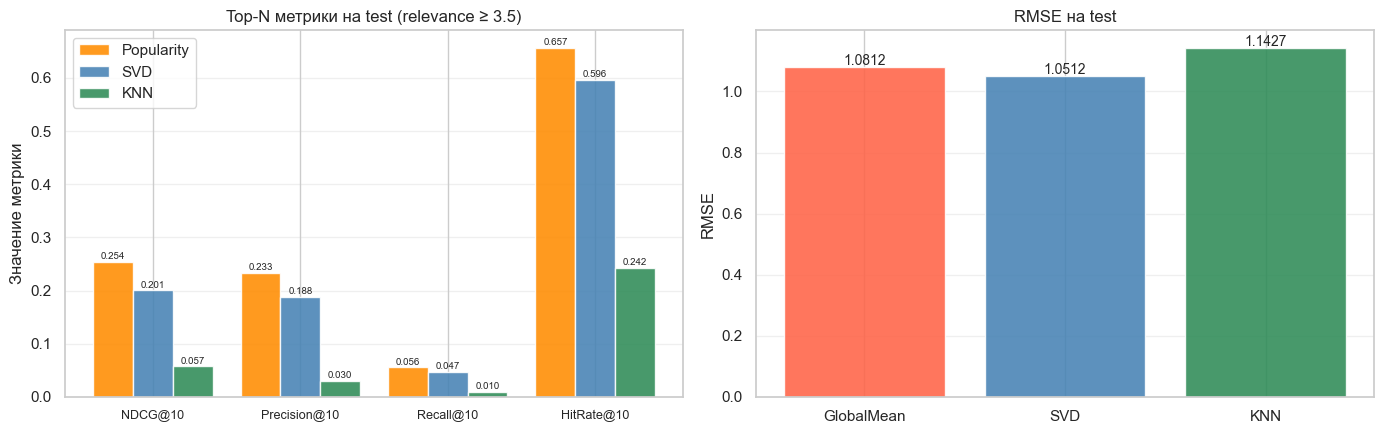

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

topn_metrics_names = ['NDCG@10', 'Precision@10', 'Recall@10', 'HitRate@10']
models_topn        = ['Popularity', 'SVD', 'KNN (this notebook)']
labels             = ['Popularity', 'SVD', 'KNN']
x = np.arange(len(topn_metrics_names))
width = 0.27
colors = ['darkorange', 'steelblue', 'seagreen']

for i, (model_name, label, color) in enumerate(zip(models_topn, labels, colors)):
    row  = comparison_df[comparison_df['Модель'] == model_name].iloc[0]
    vals = [float(row[m]) if row[m] is not None else 0.0
            for m in topn_metrics_names]
    bars = axes[0].bar(x + i * width, vals, width, label=label,
                       color=color, alpha=0.88, edgecolor='white')
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{v:.3f}', ha='center', fontsize=7)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(topn_metrics_names, fontsize=9)
axes[0].set_title(f'Top-N метрики на test (relevance ≥ {RELEVANCE_THRESHOLD})')
axes[0].set_ylabel('Значение метрики')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# RMSE comparison
rmse_models = ['GlobalMean', 'SVD', 'KNN']
rmse_colors = ['tomato', 'steelblue', 'seagreen']
rmse_vals = [gm_test['rmse'], svd_test_rating['rmse'],
             knn_test_rating_metrics['rmse']]
bars = axes[1].bar(rmse_models, rmse_vals, color=rmse_colors,
                   alpha=0.88, edgecolor='white')
axes[1].set_title('RMSE на test')
axes[1].set_ylabel('RMSE')
axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'knn_vs_baseline.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Интерпретируемость рекомендаций

Главное преимущество item-based KNN перед SVD — **объяснимость**.
Для каждой рекомендации можно показать похожие фильмы, которые её обосновывают.
Это ценно как для UX («рекомендуем X, потому что вам понравился Y»),
так и для диагностики модели.

Показываем для одного test-пользователя:
1. Историю с высокими оценками (train+val)
2. Топ-5 рекомендаций KNN
3. Для каждой рекомендации — топ-3 наиболее похожих фильма из всей библиотеки

> Если cosine similarity у всех соседей = 0.0 — модель рекомендует «вслепую».
> Это прямое следствие разреженности матрицы: у редких фильмов нет пар с общими оценщиками.


In [17]:
# ── Берём первого test-пользователя ────────────────────────────────────
sample_user = test_users[0]
sample_recs = test_recs[sample_user][:5]

# История пользователя в train+val (высоко оценённые фильмы)
user_history = (
    train_val[
        (train_val['userId'] == sample_user) & (train_val['rating'] >= 4.0)
    ]
    .merge(movies_enriched[['movieId', 'title']], on='movieId')
    .sort_values('rating', ascending=False)
)

print(f'Пример пользователя: userId={sample_user}')
print(f'\nВысоко оценённые фильмы (rating ≥ 4.0, топ-10):')
display(user_history[['title', 'rating']].head(10))

print(f'\nТоп-5 рекомендаций KNN для userId={sample_user}:')
recs_with_titles = pd.DataFrame({
    'movieId': sample_recs,
    'title':   [movies_enriched.set_index('movieId').loc[m, 'title']
                for m in sample_recs],
})
display(recs_with_titles)

Пример пользователя: userId=15

Высоко оценённые фильмы (rating ≥ 4.0, топ-10):


,title,rating
0,Lethal Weapon 2 (1989),5.0
1,"Gods Must Be Crazy, The (1980)",5.0
2,Frequency (2000),5.0
3,What Women Want (2000),4.0
4,U-571 (2000),4.0
5,(500) Days of Summer (2009),4.0



Топ-5 рекомендаций KNN для userId=15:


,movieId,title
0,168252,Logan (2017)
1,32387,"Sword of Doom, The (Dai-bosatsu tôge) (1966)"
2,6442,Belle époque (1992)
3,6994,"Hard Way, The (1991)"
4,4444,"Way of the Dragon, The (a.k.a. Return of the D..."


In [18]:
# ── Топ-3 похожих фильма для каждой рекомендации (из ВСЕЙ библиотеки) ───
sim_matrix = final_knn.sim       # shape (n_items_inner, n_items_inner)
inner_id_of = trainset_full.to_inner_iid
raw_id_of   = trainset_full.to_raw_iid
title_lookup = movies_enriched.set_index('movieId')['title']

explanations = []
for rec_movie in sample_recs:
    try:
        inner_rec = inner_id_of(rec_movie)
    except ValueError:
        continue
    # Similarity рекомендованного со всеми остальными
    sims = sim_matrix[inner_rec].copy()
    sims[inner_rec] = -np.inf   # исключаем сам фильм
    top3_inner = np.argsort(-sims)[:3]
    rec_title = title_lookup.get(rec_movie, f'movie_{rec_movie}')
    for inner_sim_movie in top3_inner:
        raw_sim_movie = raw_id_of(int(inner_sim_movie))
        sim_title = title_lookup.get(raw_sim_movie, f'movie_{raw_sim_movie}')
        explanations.append({
            'Рекомендовано':    rec_title,
            'Похожий фильм':    sim_title,
            'Cosine similarity': round(float(sims[inner_sim_movie]), 4),
        })

print('Топ-3 похожих фильма для каждой рекомендации (из всей библиотеки):')
display(pd.DataFrame(explanations))

Топ-3 похожих фильма для каждой рекомендации (из всей библиотеки):


,Рекомендовано,Похожий фильм,Cosine similarity
0,Logan (2017),"Baby-Sitters Club, The (1995)",0.0
1,Logan (2017),Quick Change (1990),0.0
2,Logan (2017),"Woman of Paris, A (1923)",0.0
3,"Sword of Doom, The (Dai-bosatsu tôge) (1966)","Baby-Sitters Club, The (1995)",0.0
4,"Sword of Doom, The (Dai-bosatsu tôge) (1966)","Woman of Paris, A (1923)",0.0
5,"Sword of Doom, The (Dai-bosatsu tôge) (1966)",Captain Blood (1935),0.0
6,Belle époque (1992),"Baby-Sitters Club, The (1995)",0.0
7,Belle époque (1992),Quick Change (1990),0.0
8,Belle époque (1992),"Woman of Paris, A (1923)",0.0
9,"Hard Way, The (1991)","Baby-Sitters Club, The (1995)",0.0


In [24]:

user_high_rated_set = set(user_history['movieId'].tolist())

print('Пересечение топ-10 похожих с историей пользователя:\n')
for rec_movie in sample_recs:
    try:
        inner_rec = inner_id_of(rec_movie)
    except ValueError:
        continue
    sims = sim_matrix[inner_rec].copy()
    sims[inner_rec] = -np.inf
    top10_inner = np.argsort(-sims)[:10]
    raw_top10 = [raw_id_of(int(i)) for i in top10_inner]
    intersection = [m for m in raw_top10 if m in user_high_rated_set]

    rec_title = title_lookup.get(rec_movie, f'movie_{rec_movie}')
    if intersection:
        names = [title_lookup.get(m, str(m)) for m in intersection]
        print(f'  «{rec_title}»  ----  похожи на: {names}')
    else:
        print(f'  «{rec_title}»  ----  нет совпадений с историей в топ-10')

Пересечение топ-10 похожих с историей пользователя:

  «Logan (2017)»  ----  нет совпадений с историей в топ-10
  «Sword of Doom, The (Dai-bosatsu tôge) (1966)»  ----  нет совпадений с историей в топ-10
  «Belle époque (1992)»  ----  нет совпадений с историей в топ-10
  «Hard Way, The (1991)»  ----  нет совпадений с историей в топ-10
  «Way of the Dragon, The (a.k.a. Return of the Dragon) (Meng long guo jiang) (1972)»  ----  нет совпадений с историей в топ-10


## 9. Анализ ошибок

Два среза:
- **Топ фильмов с максимальной средней |ошибкой|** — где KNN промахивается сильнее всего.
- **Корреляция ошибки с популярностью фильма** — популярные фильмы
  предсказываются точнее: у них больше соседей с ненулевым сходством.


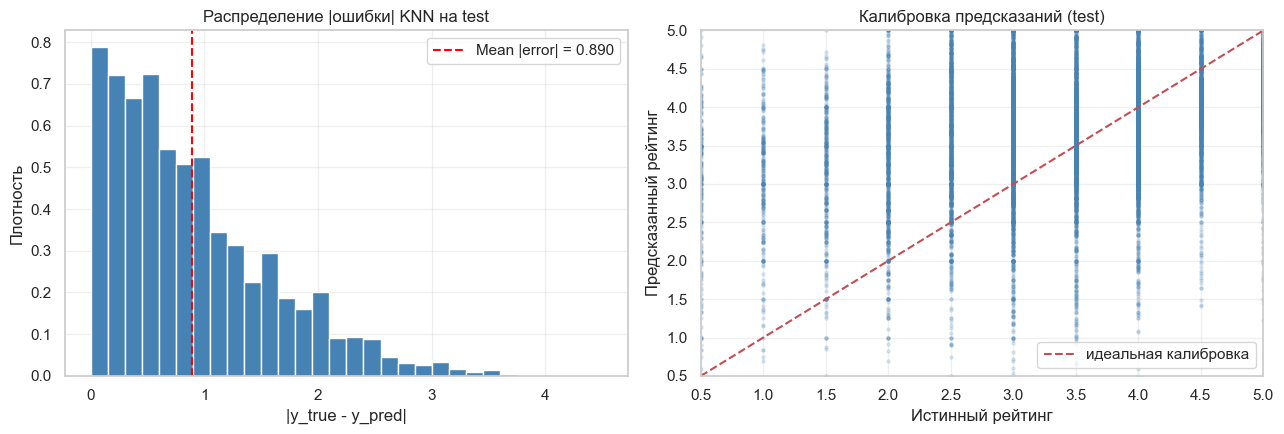

Диапазон предсказаний: [0.50, 5.00]
Std предсказаний: 0.806  (std истинных оценок: 1.071)


In [20]:
# DataFrame с ошибками
test_with_errors = test.copy()
test_with_errors['pred']  = test_preds
test_with_errors['error'] = np.abs(test['rating'].values - test_preds)

# 1. Гистограмма ошибок и scatter истинный vs предсказанный
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(test_with_errors['error'], bins=30, color='steelblue',
             edgecolor='white', density=True)
axes[0].axvline(test_with_errors['error'].mean(), color='red',
                linestyle='--',
                label=f'Mean |error| = {test_with_errors["error"].mean():.3f}')
axes[0].set_title('Распределение |ошибки| KNN на test')
axes[0].set_xlabel('|y_true - y_pred|')
axes[0].set_ylabel('Плотность')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(test_with_errors['rating'], test_with_errors['pred'],
                alpha=0.15, s=5, color='steelblue')
lims = [0.5, 5.0]
axes[1].plot(lims, lims, 'r--', linewidth=1.5,
             label='идеальная калибровка')
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel('Истинный рейтинг')
axes[1].set_ylabel('Предсказанный рейтинг')
axes[1].set_title('Калибровка предсказаний (test)')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Контроль regression to mean ────────────────────────────────────────
print(f'Диапазон предсказаний: [{test_preds.min():.2f}, {test_preds.max():.2f}]')
print(f'Std предсказаний: {test_preds.std():.3f}  '
      f'(std истинных оценок: {test["rating"].std():.3f})')

In [21]:
# 2. Топ-10 фильмов с наибольшей средней ошибкой
movie_error = (
    test_with_errors
    .groupby('movieId')['error']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'mean_error', 'count': 'n_test'})
)
movie_error = movie_error[movie_error['n_test'] >= 3]
top_movie_errors = (
    movie_error.nlargest(10, 'mean_error')
    .merge(movies_enriched[['movieId', 'title']], on='movieId', how='left')
)
top_movie_errors['mean_error'] = top_movie_errors['mean_error'].round(3)
print('Топ-10 фильмов с наибольшей средней |ошибкой| (>= 3 оценки в test):')
display(top_movie_errors[['title', 'mean_error', 'n_test']])

Топ-10 фильмов с наибольшей средней |ошибкой| (>= 3 оценки в test):


,title,mean_error,n_test
0,Sense and Sensibility (1995),2.755,3
1,Insurgent (2015),2.000,3
2,Orange County (2002),1.898,3
3,Joe Dirt (2001),1.812,3
4,Cliffhanger (1993),1.786,4
5,WarGames (1983),1.760,3
6,Sky High (2005),1.750,4
7,Rush Hour 3 (2007),1.750,3
8,Ghost Ship (2002),1.750,3
9,Talladega Nights: The Ballad of Ricky Bobby (2...,1.742,6


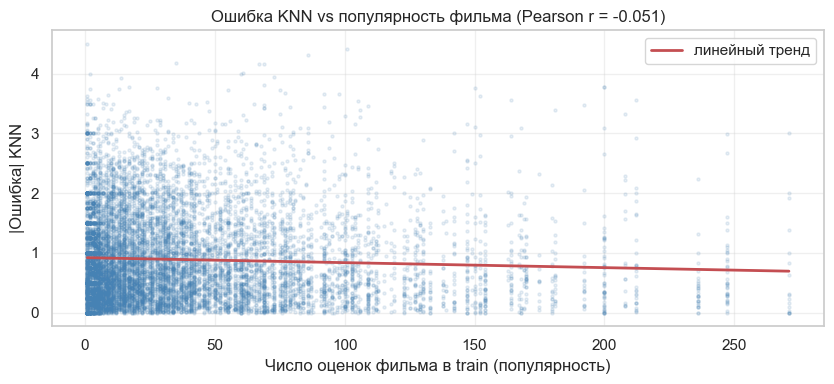

Pearson r (ошибка vs популярность): -0.0510
Отрицательная корреляция -> популярные фильмы предсказываются точнее.
Это ожидаемо: у них больше соседей с ненулевой similarity.


In [22]:
# 3. Корреляция ошибки с популярностью фильма в train
movie_pop_train = train.groupby('movieId').size().reset_index(name='n_ratings_train')
error_vs_pop = test_with_errors.merge(movie_pop_train, on='movieId', how='left')

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.scatter(error_vs_pop['n_ratings_train'], error_vs_pop['error'],
           alpha=0.12, s=5, color='steelblue')

x_vals = error_vs_pop['n_ratings_train'].values
y_vals = error_vs_pop['error'].values
mask   = ~np.isnan(x_vals) & ~np.isnan(y_vals)

# np.polyfit returns [highest_degree_coef, ..., intercept]
slope, intercept = np.polyfit(x_vals[mask], y_vals[mask], 1)
x_line = np.linspace(x_vals[mask].min(), x_vals[mask].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2,
        label='линейный тренд')

corr = np.corrcoef(x_vals[mask], y_vals[mask])[0, 1]
ax.set_xlabel('Число оценок фильма в train (популярность)')
ax.set_ylabel('|Ошибка| KNN')
ax.set_title(f'Ошибка KNN vs популярность фильма (Pearson r = {corr:.3f})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Pearson r (ошибка vs популярность): {corr:.4f}')
if corr < 0:
    print('Отрицательная корреляция -> популярные фильмы предсказываются точнее.')
    print('Это ожидаемо: у них больше соседей с ненулевой similarity.')

## 10. Сохранение артефактов

Surprise сохраняет в pickle полную матрицу сходства размером `n_items × n_items`
(для item-based) или `n_users × n_users` (для user-based).
Для 5446 фильмов это ~240 MB — архитектурное ограничение библиотеки.

> В продакшне стоит реализовать sparse-вариант через `scipy.sparse`
> или перейти на `implicit`, который хранит только ненулевые сходства.


In [23]:
# Модель
joblib.dump(final_knn, MODELS_DIR / 'knn_model.pkl')
size_mb = (MODELS_DIR / 'knn_model.pkl').stat().st_size / 1024 / 1024
print(f"knn_model.pkl: {size_mb:.1f} MB")

# Параметры
knn_params = {
    'random_state':                SEED,
    'best_params':                 study.best_params,
    'fixed_user_based':            FIXED_USER_BASED,
    'fixed_sim_name':              FIXED_SIM_NAME,
    'optuna_n_trials':             N_TRIALS,
    'optuna_sampler':              'TPESampler',
    'optuna_direction':            'minimize',
    'optuna_target':               f'-ndcg@{K_PRIMARY} on val',
    'relevance_threshold':         RELEVANCE_THRESHOLD,
    'final_train_strategy':        'train + val concatenated',
    'baseline_train_time_sec':     baseline_train_time,
    'optuna_search_time_sec':      optuna_time,
    'final_train_time_sec':        final_train_time,
    'inference_time_test_topn_sec': inference_time,
}
with open(MODELS_DIR / 'knn_params.json', 'w', encoding='utf-8') as f:
    json.dump(knn_params, f, ensure_ascii=False, indent=2)

# Метрики
knn_metrics = {
    'baseline': {
        'val_rating': baseline_val_rating,
        'val_topn':   baseline_val_topn,
    },
    'final': {
        'val_best_ndcg10': float(best_ndcg10_val),
        'test_rating':     knn_test_rating_metrics,
        'test_topn':       knn_test_topn_metrics,
    },
    'popularity_recomputed_unified_threshold': pop_test_metrics_unified,
    'meta': {
        'k_values':              list(K_VALUES),
        'relevance_threshold':   RELEVANCE_THRESHOLD,
        'optuna_n_trials':       N_TRIALS,
        'optuna_target':         f'ndcg@{K_PRIMARY}',
    },
}
with open(MODELS_DIR / 'knn_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(knn_metrics, f, ensure_ascii=False, indent=2)

# История trials Optuna
trials_df = study.trials_dataframe()
trials_df.to_parquet(MODELS_DIR / 'knn_optuna_trials.parquet', index=False)

print('Все артефакты сохранены.')
print(f'  Лучший NDCG@{K_PRIMARY} (val): {best_ndcg10_val:.4f}')
print(f'  RMSE (test):                  {knn_test_rating_metrics["rmse"]:.4f}')
print(f'  NDCG@10 (test):               {knn_test_topn_metrics["ndcg@10"]:.4f}')
print(f'  Precision@10 (test):          {knn_test_topn_metrics["precision@10"]:.4f}')
print(f'  Coverage@20 (test):           {knn_test_topn_metrics.get("coverage@20", 0):.4f}')

knn_model.pkl: 228.5 MB
Все артефакты сохранены.
  Лучший NDCG@10 (val): 0.0337
  RMSE (test):                  1.1427
  NDCG@10 (test):               0.0573
  Precision@10 (test):          0.0303
  Coverage@20 (test):           0.0255


## 11. Итоги

| Что сделано | Результат |
|-------------|-----------|
| Item-based KNNWithMeans, cosine, Optuna 20 trials по NDCG@10 | best NDCG@10 val = 0.0337 |
| Оценка по RMSE/MAE и top-N (NDCG, P, R, HR, Coverage) на test | NDCG@10 test = 0.0573 |
| Сравнение с GlobalMean, Popularity, SVD под порогом 3.5 | KNN уступает всем моделям по NDCG@10 |

**Почему KNN слабее SVD на этом датасете:**
матрица оценок крайне разреженная — 610 пользователей × 5446 фильмов.
У большинства пар фильмов нет общих оценщиков, cosine similarity = 0,
модель вынуждена рекомендовать без реальной информации о сходстве.
SVD решает эту проблему через латентное пространство, которое заполняет пробелы.

**Когда KNN имеет смысл:**
на плотных матрицах (много оценок на пользователя), в сценариях,
где критична объяснимость рекомендаций, или как компонент ансамбля.
